In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import roc_auc_score,confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import OneHotEncoder

from data_process import process_raw_data, process_curated_data, data_encoding

In [2]:
df_raw = process_raw_data(yr_list = [2022,2023,2024])
df_cur = process_curated_data(df_raw = df_raw)
df_encoded = data_encoding(df_cur = df_cur)

### Starting data processing
    ## Processing data of 2022
    ## Processing data of 2023
    ## Processing data of 2024


/mnt/e/github/cartola-fc/data_process.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cur['year_season'] = df_cur['year'].astype("str") + "-" + df_cur['rodada_id'].astype("str")


In [3]:
cols_x = ["apelido","rodada_id","clube_id","preco_num","media_num","jogos_num","posicao_id_ata","posicao_id_gol","posicao_id_lat","posicao_id_mei","posicao_id_tec","posicao_id_zag","media_3_rodadas","media_5_rodadas"]
col_y = ["prob_profit_loss"]

df_ml = df_encoded[cols_x + col_y]

df_ml = df_ml.dropna()

In [4]:
df_ml 

,apelido,rodada_id,clube_id,preco_num,media_num,jogos_num,posicao_id_ata,posicao_id_gol,posicao_id_lat,posicao_id_mei,posicao_id_tec,posicao_id_zag,media_3_rodadas,media_5_rodadas,prob_profit_loss
0,0,19,6,14.35,6.00,19,0.0,0.0,0.0,0.0,1.0,0.0,6.000000,6.000000,1
1,0,20,6,14.47,6.10,20,0.0,0.0,0.0,0.0,1.0,0.0,6.050000,6.050000,1
2,0,21,6,14.48,6.16,21,0.0,0.0,0.0,0.0,1.0,0.0,6.086667,6.086667,0
3,0,22,6,14.47,6.15,22,0.0,0.0,0.0,0.0,1.0,0.0,6.136667,6.102500,1
4,0,23,6,14.68,6.20,23,0.0,0.0,0.0,0.0,1.0,0.0,6.170000,6.122000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15079,688,5,14,3.93,1.80,4,0.0,0.0,1.0,0.0,0.0,0.0,2.100000,2.100000,0
15080,688,6,14,3.79,1.68,5,0.0,0.0,1.0,0.0,0.0,0.0,1.960000,1.960000,1
15083,689,9,18,6.45,9.70,1,0.0,0.0,0.0,1.0,0.0,0.0,9.700000,9.700000,0
15081,689,10,18,5.90,5.45,2,0.0,0.0,0.0,1.0,0.0,0.0,7.575000,7.575000,0


In [6]:
X = df_ml[cols_x].values
y = df_ml[col_y].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [7]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,  # Limite na profundidade para evitar overfitting
    min_samples_split=10,  # Exige mais amostras para criar um novo split
    min_samples_leaf=5,  # Exige que cada folha tenha pelo menos 5 amostras
    random_state=42
)
rf.fit(X_train,y_train)

/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [8]:
y_pred = rf.predict(X_test)
rf_score = rf.score(X_test,y_test)

print(f"Random Forest Score: {rf_score}")

Random Forest Score: 0.02656040447980823


In [11]:
cval_rf = cross_val_score(rf,X_train,y_train, cv=5)

print(f"Random Forest Cross Val Score {cval_rf}")

/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column

Random Forest Cross Val Score [0.04745438 0.06914014 0.06207543 0.06120175 0.0544012 ]


In [27]:
import pickle

# Nome do arquivo onde o modelo será salvo
model_filename = 'random_forest_model.pkl'

# Salvar o modelo
with open(model_filename, 'wb') as file:
    pickle.dump(rf, file)

print(f"Modelo salvo como {model_filename}")

Modelo salvo como random_forest_model.pkl


/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/tmp/ipykernel_9985/3159702915.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette="viridis")


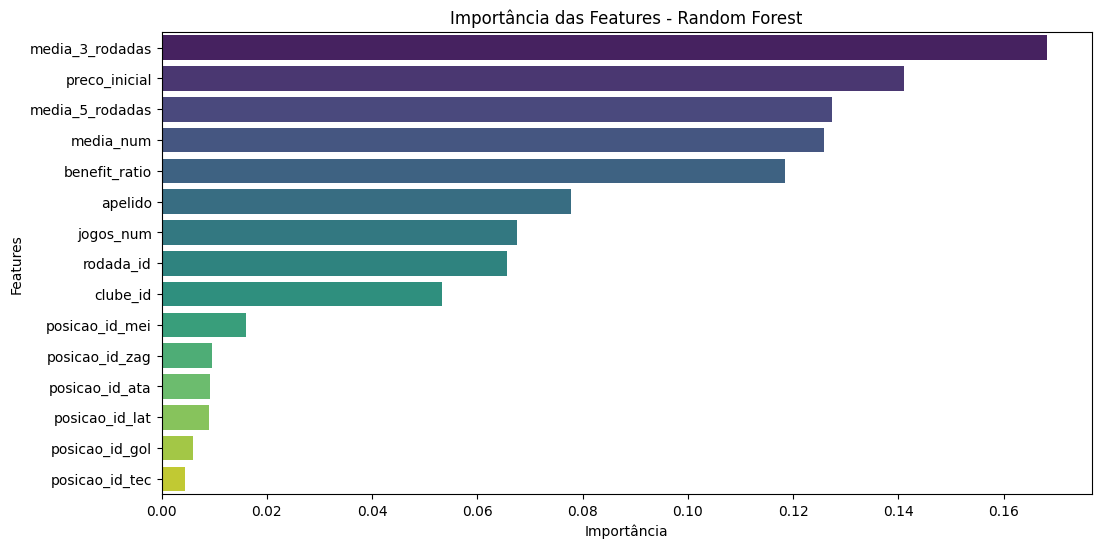

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Treinar o modelo (exemplo)
rf.fit(X_train, y_train)

# Obter importância das features
feature_importances = pd.DataFrame({
    'Feature': df_ml[cols_x].columns,
    'Importance': rf.feature_importances_
})

# Ordenar pela importância
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Criar o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette="viridis")

# Ajustes visuais
plt.xlabel("Importância")
plt.ylabel("Features")
plt.title("Importância das Features - Random Forest")
plt.show()


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1️⃣ Inicializar o modelo
lr = LinearRegression()

# 2️⃣ Treinar o modelo
lr.fit(X_train, y_train)

# 3️⃣ Fazer previsões
y_pred = lr.predict(X_test)

# 4️⃣ Avaliar o modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 2.7181
Mean Squared Error (MSE): 12.7321
R² Score: 0.0759


In [12]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

/home/vmattos/anaconda3/envs/conda3.11/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.85      0.69      2534
           1       0.56      0.23      0.33      1992

    accuracy                           0.58      4526
   macro avg       0.57      0.54      0.51      4526
weighted avg       0.57      0.58      0.53      4526



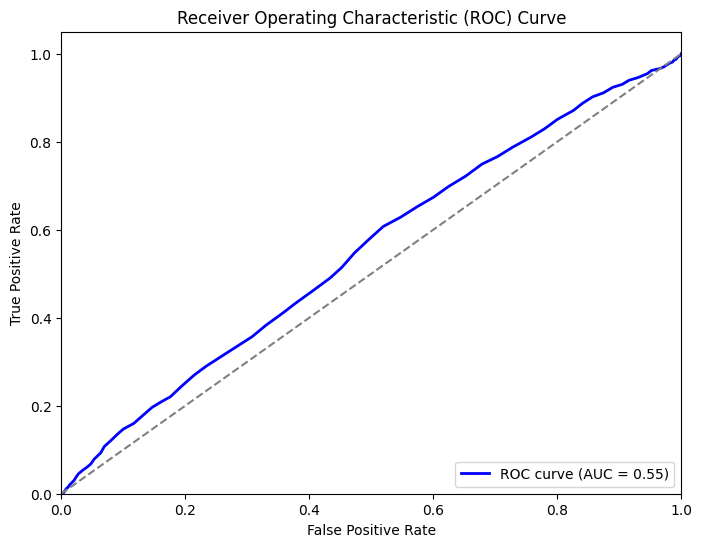

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1️⃣ Get predicted probabilities (for positive class)
y_probs = rf_classifier.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# 2️⃣ Compute the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)  
roc_auc = auc(fpr, tpr)  # Compute AUC score

# 3️⃣ Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [15]:
df_test = df_ml.copy()



y_pred_test = log_reg.predict_proba(X)

In [20]:
y_pred_test[1]

array([0.64581291, 0.35418709])

In [22]:
df = pd.DataFrame(X,columns=cols_x)
df[['prob_win','prob_loose']] = y_pred_test

In [34]:
df

,apelido,rodada_id,clube_id,preco_num,media_num,jogos_num,posicao_id_ata,posicao_id_gol,posicao_id_lat,posicao_id_mei,posicao_id_tec,posicao_id_zag,media_3_rodadas,media_5_rodadas,prob_win,prob_loose
0,0.0,19.0,6.0,14.35,6.00,19.0,0.0,0.0,0.0,0.0,1.0,0.0,6.000000,6.000000,0.641222,0.358778
1,0.0,20.0,6.0,14.47,6.10,20.0,0.0,0.0,0.0,0.0,1.0,0.0,6.050000,6.050000,0.645813,0.354187
2,0.0,21.0,6.0,14.48,6.16,21.0,0.0,0.0,0.0,0.0,1.0,0.0,6.086667,6.086667,0.645388,0.354612
3,0.0,22.0,6.0,14.47,6.15,22.0,0.0,0.0,0.0,0.0,1.0,0.0,6.136667,6.102500,0.637212,0.362788
4,0.0,23.0,6.0,14.68,6.20,23.0,0.0,0.0,0.0,0.0,1.0,0.0,6.170000,6.122000,0.640606,0.359394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15079,688.0,5.0,14.0,3.93,1.80,4.0,0.0,0.0,1.0,0.0,0.0,0.0,2.100000,2.100000,0.445626,0.554374
15080,688.0,6.0,14.0,3.79,1.68,5.0,0.0,0.0,1.0,0.0,0.0,0.0,1.960000,1.960000,0.442338,0.557662
15081,689.0,9.0,18.0,6.45,9.70,1.0,0.0,0.0,0.0,1.0,0.0,0.0,9.700000,9.700000,0.603800,0.396200
15082,689.0,10.0,18.0,5.90,5.45,2.0,0.0,0.0,0.0,1.0,0.0,0.0,7.575000,7.575000,0.339865,0.660135


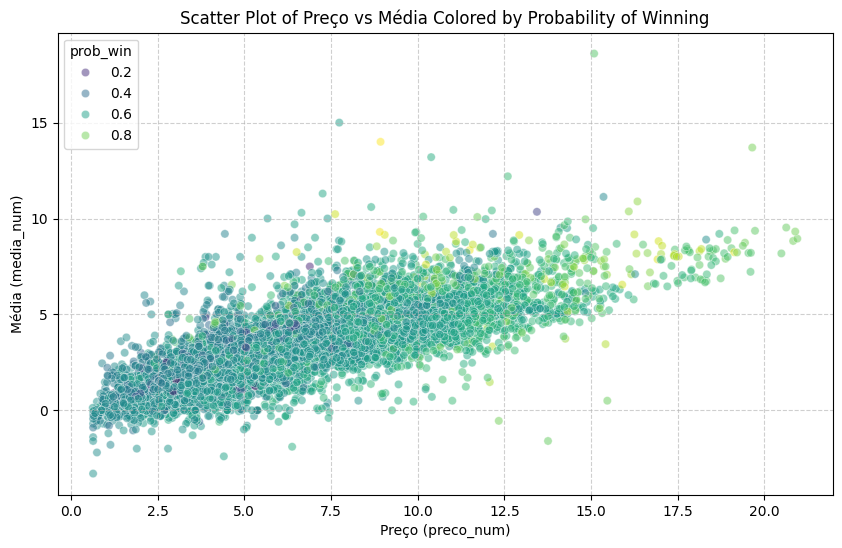

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt



# Assuming df is your DataFrame and 'prob_win' contains the predicted probabilities
# Create a scatter plot with Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='preco_num', 
    y='media_num', 
    hue='prob_win',  # Color points by probability of winning
    data=df, 
    palette='viridis',  # Use a color palette
    # size='prob_win',   # Optional: Adjust point size based on probability
    sizes=(20, 200),   # Range of point sizes
    alpha=0.5         # Add transparency for better visualization
)

# Add a color bar for the probability
norm = plt.Normalize(df['prob_win'].min(), df['prob_win'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
# plt.colorbar(sm, label='Probability of Winning')

# Add labels and title
plt.xlabel('Preço (preco_num)')
plt.ylabel('Média (media_num)')
plt.title('Scatter Plot of Preço vs Média Colored by Probability of Winning')

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

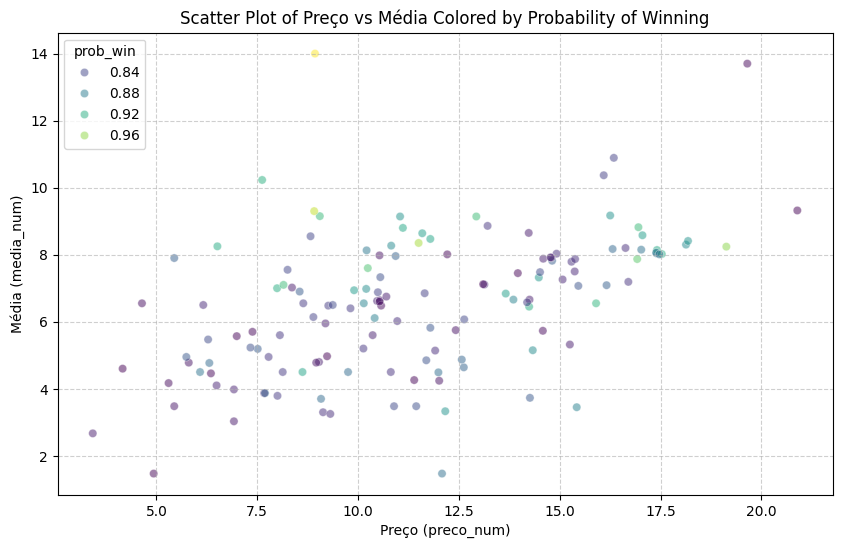

In [33]:
df_filter = df[df['prob_win']> 0.8]


import seaborn as sns
import matplotlib.pyplot as plt



# Assuming df is your DataFrame and 'prob_win' contains the predicted probabilities
# Create a scatter plot with Seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='preco_num', 
    y='media_num', 
    hue='prob_win',  # Color points by probability of winning
    data=df_filter, 
    palette='viridis',  # Use a color palette
    # size='prob_win',   # Optional: Adjust point size based on probability
    sizes=(20, 200),   # Range of point sizes
    alpha=0.5         # Add transparency for better visualization
)

# Add a color bar for the probability
norm = plt.Normalize(df['prob_win'].min(), df['prob_win'].max())
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
# plt.colorbar(sm, label='Probability of Winning')

# Add labels and title
plt.xlabel('Preço (preco_num)')
plt.ylabel('Média (media_num)')
plt.title('Scatter Plot of Preço vs Média Colored by Probability of Winning')

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()